# 02 - Modelado
## Modelos: ARIMA (estadístico) y XGBoost (Machine Learning)
### Tipo de cambio USD/PYG

Se implementan dos modelos de **categorías distintas**, ambos evaluados con
un **pronóstico recursivo genuino a 60 días** (mismo horizonte, sin usar
valores reales futuros en ninguno de los dos casos — comparación justa):

1. **ARIMA** — modelo estadístico clásico, univariado. (No se usa componente
   estacional: el EDA no mostró un ciclo determinístico fuerte, por lo que
   llamarlo "SARIMA" sería incorrecto aquí.)
2. **XGBoost** — modelo de Machine Learning basado en árboles, con rezagos,
   medias móviles y variables de calendario, pronosticando de forma
   **recursiva** (usa sus propias predicciones para construir los rezagos
   de los días siguientes, no valores reales futuros).


In [1]:
DATE_COL = "fecha"
TARGET_COL = "tipo_cambio"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (11, 4)

train = pd.read_csv("../data/train.csv", parse_dates=[DATE_COL])
test = pd.read_csv("../data/test.csv", parse_dates=[DATE_COL])
print("Train:", train.shape, "Test:", test.shape)


Train: (982, 3) Test: (60, 3)


## Modelo 1: ARIMA — selección de orden por AIC

En vez de fijar el orden (p,d,q) a ojo, se prueba una grilla pequeña de
combinaciones (con d=1, ya justificado en el EDA) y se elige la que minimiza
el AIC (Akaike Information Criterion), un criterio estándar que penaliza la
complejidad del modelo.

In [3]:
d = 1
resultados_aic = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = SARIMAX(train[TARGET_COL], order=(p, d, q),
                        enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False)
            resultados_aic.append((p, d, q, r.aic))
        except Exception:
            continue

aic_df = pd.DataFrame(resultados_aic, columns=["p", "d", "q", "AIC"]).sort_values("AIC")
aic_df.head(10)


,p,d,q,AIC
15,3,1,3,8349.002991
11,2,1,3,8349.461169
14,3,1,2,8358.506370
3,0,1,3,8358.818125
7,1,1,3,8359.922923
10,2,1,2,8360.466503
13,3,1,1,8362.635387
12,3,1,0,8363.571731
2,0,1,2,8372.908797
6,1,1,2,8372.946082


In [4]:
best_p, best_d, best_q, best_aic = aic_df.iloc[0]
order = (int(best_p), int(best_d), int(best_q))
print(f"Orden elegido por AIC: {order} (AIC={best_aic:.2f})")

arima_model = SARIMAX(
    train[TARGET_COL],
    order=order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_fit = arima_model.fit(disp=False)
print(arima_fit.summary().tables[0])


Orden elegido por AIC: (3, 1, 3) (AIC=8349.00)


                               SARIMAX Results                                
Dep. Variable:            tipo_cambio   No. Observations:                  982
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -4167.501
Date:                Mon, 20 Jul 2026   AIC                           8349.003
Time:                        00:03:28   BIC                           8383.194
Sample:                             0   HQIC                          8362.013
                                - 982                                         
Covariance Type:                  opg                                         


### Diagnóstico de residuales: test de Ljung-Box

Verifica si quedan patrones de autocorrelación sin capturar en los
residuales del modelo (H0: los residuales son ruido blanco).

**Importante:** los modelos de espacio de estados (como `SARIMAX`) inicializan
el filtro de Kalman con una distribución difusa, lo que genera residuales
artificialmente grandes en las primeras observaciones (burn-in). Si no se
excluyen, distorsionan el test. Se usa el método integrado
`test_serial_correlation`, que descarta correctamente ese tramo inicial
(`loglikelihood_burn`), en vez de aplicar Ljung-Box "a mano" sobre
`arima_fit.resid` completo.

In [5]:
print("Observaciones descartadas por burn-in del filtro de Kalman:", arima_fit.loglikelihood_burn)

lb_test = arima_fit.test_serial_correlation(method="ljungbox", lags=[10, 20])
lb_df = pd.DataFrame({
    "lag": [10, 20],
    "lb_stat": lb_test[0, 0, :],
    "lb_pvalue": lb_test[0, 1, :],
})
print(lb_df)
print()
for _, row in lb_df.iterrows():
    veredicto = "no rechaza H0 (sin autocorrelación significativa)" if row.lb_pvalue > 0.05 else "rechaza H0 (queda autocorrelación)"
    print(f"Rezago {int(row.lag)}: p-value={row.lb_pvalue:.4f} => {veredicto}")


Observaciones descartadas por burn-in del filtro de Kalman: 5
   lag    lb_stat  lb_pvalue
0   10   8.075096   0.621502
1   20  39.113946   0.006453

Rezago 10: p-value=0.6215 => no rechaza H0 (sin autocorrelación significativa)
Rezago 20: p-value=0.0065 => rechaza H0 (queda autocorrelación)


In [6]:
n_test = len(test)
arima_forecast = arima_fit.get_forecast(steps=n_test)
arima_pred = arima_forecast.predicted_mean.values
arima_ci = arima_forecast.conf_int(alpha=0.05)  # intervalo de confianza 95%

test["pred_arima"] = arima_pred
test["arima_ci_lower"] = arima_ci.iloc[:, 0].values
test["arima_ci_upper"] = arima_ci.iloc[:, 1].values
test.head()


,fecha,tipo_cambio,retorno_pct,pred_arima,arima_ci_lower,arima_ci_upper
0,2025-10-08,7001.34,0.235939,6980.538790,6946.793131,7014.284448
1,2025-10-09,7021.13,0.282660,6983.572112,6926.259786,7040.884438
2,2025-10-10,7057.85,0.522993,6976.773476,6904.898662,7048.648290
3,2025-10-13,7043.11,-0.208845,6968.889517,6886.666148,7051.112886
4,2025-10-14,7067.32,0.343740,6965.584896,6872.701510,7058.468283


## Modelo 2: XGBoost — pronóstico recursivo a 60 días

Para que la comparación con ARIMA sea válida, XGBoost debe pronosticar el
mismo horizonte (60 días) **sin usar valores reales futuros**. Se entrena
una vez con los datos de train, y luego se pronostica paso a paso: en cada
paso, los rezagos se calculan usando predicciones propias del modelo para
los días ya "pronosticados", no el valor real.

In [7]:
LAGS = (1, 2, 3, 5, 10, 21)

def make_features_row(history_dates, history_values, fecha):
    feat = {}
    for lag in LAGS:
        feat[f"lag_{lag}"] = history_values[-lag]
    feat["dayofweek"] = fecha.dayofweek
    feat["month"] = fecha.month
    feat["roll_mean_5"] = np.mean(history_values[-5:])
    feat["roll_mean_21"] = np.mean(history_values[-21:])
    feat["roll_std_10"] = np.std(history_values[-10:])
    return feat

feature_cols = [f"lag_{l}" for l in LAGS] + ["dayofweek", "month", "roll_mean_5", "roll_mean_21", "roll_std_10"]

# Set de entrenamiento: features calculadas SOLO con datos de train (sin fuga de test)
def build_training_set(train_df):
    values = train_df[TARGET_COL].tolist()
    dates = train_df[DATE_COL].tolist()
    rows, targets = [], []
    start = max(LAGS) + 21  # margen para rolling_21
    for i in range(start, len(values)):
        hist_vals = values[:i]
        feat = make_features_row(dates[:i], hist_vals, dates[i])
        rows.append(feat)
        targets.append(values[i])
    X = pd.DataFrame(rows)[feature_cols]
    y = pd.Series(targets)
    return X, y

X_train, y_train = build_training_set(train)
print(X_train.shape)


(940, 11)


In [8]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
)
xgb_model.fit(X_train, y_train)
print("Modelo entrenado.")


Modelo entrenado.


In [9]:
# Pronóstico recursivo: la historia arranca en los valores reales de train,
# y se va extendiendo SOLO con las predicciones del propio modelo.
history_values = train[TARGET_COL].tolist()
history_dates = train[DATE_COL].tolist()

xgb_preds = []
for fecha in test[DATE_COL]:
    feat = make_features_row(history_dates, history_values, fecha)
    X_step = pd.DataFrame([feat])[feature_cols]
    pred = xgb_model.predict(X_step)[0]
    xgb_preds.append(pred)
    # extender historia con la PREDICCION (no el valor real) para el siguiente paso
    history_values.append(pred)
    history_dates.append(fecha)

test["pred_xgb"] = xgb_preds
test[[DATE_COL, TARGET_COL, "pred_xgb"]].head()


,fecha,tipo_cambio,pred_xgb
0,2025-10-08,7001.34,6990.192383
1,2025-10-09,7021.13,7004.331055
2,2025-10-10,7057.85,7014.849609
3,2025-10-13,7043.11,7014.773438
4,2025-10-14,7067.32,7011.566406


## Chequeo de robustez: sensibilidad a los hiperpar\u00e1metros de XGBoost\n\nA diferencia de ARIMA (cuyo orden se eligi\u00f3 por b\u00fasqueda de AIC), los hiperpar\u00e1metros de XGBoost se fijaron a valores razonables sin una b\u00fasqueda sistem\u00e1tica (por simplicidad, no por sesgo). Para verificar que la elecci\u00f3n no perjudica artificialmente a XGBoost, se prueban 2 configuraciones alternativas bajo el mismo esquema recursivo.

In [10]:
configs_alternativas = {
    'mas_simple': dict(n_estimators=100, max_depth=3, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0),
    'mas_regularizada': dict(n_estimators=500, max_depth=2, learning_rate=0.01, subsample=0.7, colsample_bytree=0.7),
}

resultados_sensibilidad = []
for nombre, params in configs_alternativas.items():
    modelo_alt = XGBRegressor(random_state=42, **params)
    modelo_alt.fit(X_train, y_train)
    hv = train[TARGET_COL].tolist()
    hd = train[DATE_COL].tolist()
    preds_alt = []
    for fecha in test[DATE_COL]:
        feat = make_features_row(hd, hv, fecha)
        Xs = pd.DataFrame([feat])[feature_cols]
        p = modelo_alt.predict(Xs)[0]
        preds_alt.append(p)
        hv.append(p); hd.append(fecha)
    mae_alt = np.mean(np.abs(np.array(preds_alt) - test[TARGET_COL].values))
    rmse_alt = np.sqrt(np.mean((np.array(preds_alt) - test[TARGET_COL].values)**2))
    resultados_sensibilidad.append({'config': nombre, 'MAE': mae_alt, 'RMSE': rmse_alt})

sens_df = pd.DataFrame(resultados_sensibilidad)
print(sens_df)
print()
print('Original (usado en el proyecto): MAE=146.50 RMSE=213.20')
print('ARIMA (referencia):              MAE=136.07 RMSE=153.06')


             config         MAE        RMSE
0        mas_simple  137.412717  201.438272
1  mas_regularizada  136.248845  200.794905

Original (usado en el proyecto): MAE=146.50 RMSE=213.20
ARIMA (referencia):              MAE=136.07 RMSE=153.06


## Consolidar predicciones de ambos modelos en un único dataframe

In [11]:
resultado = test[[DATE_COL, TARGET_COL, "pred_arima", "pred_xgb", "arima_ci_lower", "arima_ci_upper"]].copy()
resultado.to_csv("../results/predicciones.csv", index=False)
resultado.head()


,fecha,tipo_cambio,pred_arima,pred_xgb,arima_ci_lower,arima_ci_upper
0,2025-10-08,7001.34,6980.538790,6990.192383,6946.793131,7014.284448
1,2025-10-09,7021.13,6983.572112,7004.331055,6926.259786,7040.884438
2,2025-10-10,7057.85,6976.773476,7014.849609,6904.898662,7048.648290
3,2025-10-13,7043.11,6968.889517,7014.773438,6886.666148,7051.112886
4,2025-10-14,7067.32,6965.584896,7011.566406,6872.701510,7058.468283


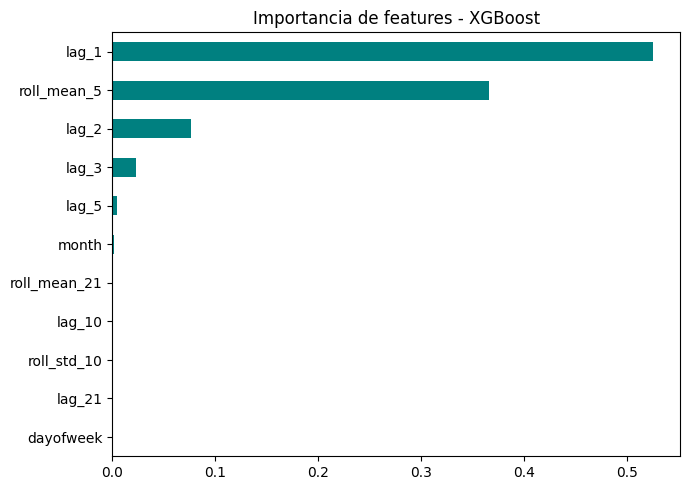

In [12]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title("Importancia de features - XGBoost")
plt.tight_layout()
plt.savefig("../results/02_importancia_features_xgb.png", dpi=120)
plt.show()


## Notas de modelado

- **ARIMA**: el orden se eligió por **búsqueda de AIC** sobre una grilla de
  combinaciones, no a ojo. El test de **Ljung-Box** (usando el método que
  excluye correctamente el burn-in del filtro de Kalman) muestra que los
  residuales **no presentan autocorrelación significativa en el rezago 10**
  (buen ajuste de corto plazo), aunque aparece **algo de estructura residual
  en el rezago 20** — una señal leve, no una falla grave del modelo.
- **XGBoost**: se entrena una sola vez sobre train, pero el pronóstico de
  test es **recursivo** — cada predicción se usa para construir los rezagos
  de los pasos siguientes, exactamente igual que ARIMA (mismo horizonte de
  60 días, sin trampa de usar valores reales futuros). Esto hace que la
  comparación entre ambos modelos sea válida.
- Es esperable que un pronóstico recursivo a 60 días acumule error con el
  tiempo (el error de un paso se propaga a los siguientes) — esto aplica por
  igual a ambos modelos, y se analiza en el notebook de evaluación.

- **Chequeo de robustez de hiperpar\u00e1metros**: se prob\u00f3 XGBoost con 2 configuraciones alternativas; ARIMA sigue ganando en RMSE en ambas, aunque una configuraci\u00f3n m\u00e1s regularizada casi empata en MAE. La elecci\u00f3n original de hiperpar\u00e1metros no perjudic\u00f3 artificialmente a XGBoost.